In [1]:
import importlib
import torch
import pandas as pd
import model_code.hidden_state_analysis as analysis
# import model_code.steering_extraction as steering_extraction
# from model_code.steering_extraction import  generateSteering, retrieve_steering_vector

importlib.reload(analysis)
# importlib.reload(steering_extraction)

<module 'model_code.hidden_state_analysis' from '/workspace/Dissertation_Project/model_code/hidden_state_analysis.py'>

In [2]:
emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors/emotion_vectors.pt")
emotion_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/emotion_vectors.pt")

steering_vector_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors.pt")
steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/steering_vectors.pt")

/tmp/ipykernel_5584/3013748282.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors/emotion_vectors.p

# Probing across different emotion across languages

## Binary Probe 

In [3]:
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']

emotion_probe = {
    'anger': 'anger',
    'happiness': 'happiness',
    'sadness': 'sadness',
    'love': 'love',
    'fear': 'fear'
}

result_stored = {}

# Training with English dataset
for emotion in all_emotions:
    # 4096 input => 1 output, binary classification
    probe = analysis.LogisticRegressionProbe(input_dim=emotion_vector_eng[emotion][0].shape[-1], output_dim=1)
    # Dataloader 
    emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(emotion_vector_eng, emotion=emotion,val_ratio=0.4)
    emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(emotion_vector_id, emotion=emotion,val_ratio=0.4)
    # Trianing the probe
    emotion_probe[emotion] = analysis.trainProbe(probe, emotion_data_eng_train, emotion_data_eng_val)
    if 'english' not in result_stored:
        result_stored['english'] = {}
    result_stored['english'][emotion] = {}
    result_stored['english'][emotion]["indonesian"] = analysis.predictProbe(emotion_probe[emotion], emotion_data_id_val)
    result_stored['english'][emotion]["english"] = analysis.predictProbe(emotion_probe[emotion], emotion_data_eng_val)


# Training with Indonesian dataset
for emotion in all_emotions:
    # 4096 input => 1 output, binary classification
    probe = analysis.LogisticRegressionProbe(input_dim=emotion_vector_id[emotion][0].shape[-1], output_dim=1)
    # Dataloader 
    emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(emotion_vector_eng, emotion=emotion,val_ratio=0.4)
    emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(emotion_vector_id, emotion=emotion,val_ratio=0.4)
    # Trianing the probe
    emotion_probe[emotion] = analysis.trainProbe(probe, emotion_data_id_train, emotion_data_id_val)
    if 'indonesian' not in result_stored:
        result_stored['indonesian'] = {}
    result_stored['indonesian'][emotion] = {}
    result_stored['indonesian'][emotion]["english"] = analysis.predictProbe(emotion_probe[emotion], emotion_data_eng_val)
    result_stored['indonesian'][emotion]["indonesian"] = analysis.predictProbe(emotion_probe[emotion], emotion_data_id_val)

/workspace/Dissertation_Project/model_code/hidden_state_analysis.py:166: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  X = torch.tensor(correct_vectors + incorrect_vectors, dtype=torch.float32)


Epoch 1/10, Loss: 0.6853
Validation Accuracy: 0.4875
Epoch 2/10, Loss: 0.6600
Validation Accuracy: 0.7656
Epoch 3/10, Loss: 0.6377
Validation Accuracy: 0.7219
Epoch 4/10, Loss: 0.6173
Validation Accuracy: 0.7688
Epoch 5/10, Loss: 0.6023
Validation Accuracy: 0.7031
Epoch 6/10, Loss: 0.5757
Validation Accuracy: 0.7500
Epoch 7/10, Loss: 0.5628
Validation Accuracy: 0.8094
Epoch 8/10, Loss: 0.5463
Validation Accuracy: 0.8094
Epoch 9/10, Loss: 0.5331
Validation Accuracy: 0.7969
Epoch 10/10, Loss: 0.5235
Validation Accuracy: 0.8094
Epoch 1/10, Loss: 0.6910
Validation Accuracy: 0.4938
Epoch 2/10, Loss: 0.6658
Validation Accuracy: 0.7438
Epoch 3/10, Loss: 0.6436
Validation Accuracy: 0.7594
Epoch 4/10, Loss: 0.6225
Validation Accuracy: 0.7219
Epoch 5/10, Loss: 0.6041
Validation Accuracy: 0.7531
Epoch 6/10, Loss: 0.5887
Validation Accuracy: 0.7562
Epoch 7/10, Loss: 0.5743
Validation Accuracy: 0.7406
Epoch 8/10, Loss: 0.5634
Validation Accuracy: 0.7438
Epoch 9/10, Loss: 0.5530
Validation Accuracy:

In [7]:
emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(emotion_vector_id, emotion='happiness',val_ratio=0.4)
emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(emotion_vector_eng, emotion='happiness',val_ratio=0.4)
trial = analysis.predictProbe(emotion_probe['sadness'], emotion_data_eng_val)
trial 

array([0.40625, 0.46875, 0.40625, 0.28125, 0.46875, 0.28125, 0.34375,
       0.5    , 0.40625, 0.53125])

In [4]:
# Summary table from the loop above
summary_rows = []
# Print English trained probe results
for emotion, lang_scores in result_stored['english'].items():
    id_scores = lang_scores["indonesian"]
    en_scores = lang_scores["english"]
    summary_rows.append({
        "emotion": emotion,
        "indonesian_mean_acc": float(id_scores.mean()),
        "english_mean_acc": float(en_scores.mean()),
        "num_eval_batches_id": len(id_scores),
        "num_eval_batches_en": len(en_scores),
    })
print("English trained probe results:")
summary_df = pd.DataFrame(summary_rows).sort_values("emotion").reset_index(drop=True)
display(summary_df)

summary_rows = []
# Print Indonesian trained probe results
for emotion, lang_scores in result_stored['indonesian'].items():
    id_scores = lang_scores["indonesian"]
    en_scores = lang_scores["english"]
    summary_rows.append({
        "emotion": emotion,
        "indonesian_mean_acc": float(id_scores.mean()),
        "english_mean_acc": float(en_scores.mean()),
        "num_eval_batches_id": len(id_scores),
        "num_eval_batches_en": len(en_scores),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("emotion").reset_index(drop=True)
print("Indonesian trained probe results:")
display(summary_df)

English trained probe results:


,emotion,indonesian_mean_acc,english_mean_acc,num_eval_batches_id,num_eval_batches_en
0,anger,0.703125,0.809375,10,10
1,fear,0.815625,0.790625,10,10
2,happiness,0.750000,0.762500,10,10
3,love,0.818750,0.818750,10,10
4,sadness,0.753125,0.750000,10,10


Indonesian trained probe results:


,emotion,indonesian_mean_acc,english_mean_acc,num_eval_batches_id,num_eval_batches_en
0,anger,0.775000,0.656250,10,10
1,fear,0.796875,0.621875,10,10
2,happiness,0.843750,0.637500,10,10
3,love,0.934375,0.543750,10,10
4,sadness,0.884375,0.665625,10,10


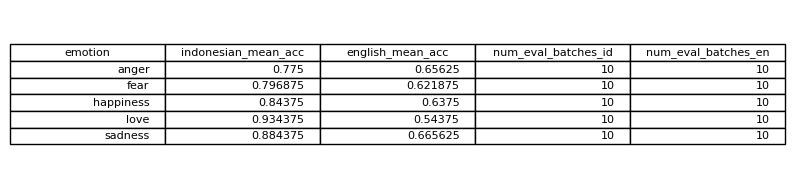

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 2.2)); ax.axis("off")
ax.table(cellText=summary_df.values, colLabels=summary_df.columns, loc="center")
fig.savefig("images/indonesian_trained_probe_results.png", dpi=300, bbox_inches="tight")
plt.show()

## Multi-Class Probe 

In [20]:
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']

result_stored = {}

# Single multiclass probe (not one-vs-rest)
probe = analysis.LogisticRegressionProbe(
    input_dim=emotion_vector_id[all_emotions[0]][0].shape[-1],
    output_dim=len(all_emotions),
)

# Build multiclass datasets using the same class order on both languages
emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(
    emotion_vector_eng,
    emotion=all_emotions[0],
    val_ratio=0.4,
    multiclass=True,
    multiclass_emotions=all_emotions,
)
emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(
    emotion_vector_id,
    emotion=all_emotions[0],
    val_ratio=0.4,
    multiclass=True,
    multiclass_emotions=all_emotions,
)

probe = analysis.trainMultiClassProbe(probe, emotion_data_id_train, emotion_data_id_val, num_epochs=25)

result_stored['multiclass'] = {}
result_stored['multiclass']['indonesian'] = analysis.predictProbe(
    probe,
    emotion_data_id_val,
    multiclass=True,
)
result_stored['multiclass']['english'] = analysis.predictProbe(
    probe,
    emotion_data_eng_val,
    multiclass=True,
)

print('Multiclass mean batch accuracy (EN):', float(result_stored['multiclass']['english'].mean()))
print('Multiclass mean batch accuracy (ID):', float(result_stored['multiclass']['indonesian'].mean()))

Epoch 1/25, Loss: 1.4747
Validation Accuracy: 0.5500
Epoch 2/25, Loss: 1.2262
Validation Accuracy: 0.7575
Epoch 3/25, Loss: 1.0568
Validation Accuracy: 0.6975
Epoch 4/25, Loss: 0.9640
Validation Accuracy: 0.7688
Epoch 5/25, Loss: 0.8518
Validation Accuracy: 0.8137
Epoch 6/25, Loss: 0.7851
Validation Accuracy: 0.7788
Epoch 7/25, Loss: 0.7295
Validation Accuracy: 0.8175
Epoch 8/25, Loss: 0.6814
Validation Accuracy: 0.8575
Epoch 9/25, Loss: 0.6445
Validation Accuracy: 0.8675
Epoch 10/25, Loss: 0.6015
Validation Accuracy: 0.8738
Epoch 11/25, Loss: 0.5714
Validation Accuracy: 0.8788
Epoch 12/25, Loss: 0.5467
Validation Accuracy: 0.8725
Epoch 13/25, Loss: 0.5237
Validation Accuracy: 0.8888
Epoch 14/25, Loss: 0.4902
Validation Accuracy: 0.8912
Epoch 15/25, Loss: 0.4669
Validation Accuracy: 0.8838
Epoch 16/25, Loss: 0.4542
Validation Accuracy: 0.8712
Epoch 17/25, Loss: 0.4356
Validation Accuracy: 0.8875
Epoch 18/25, Loss: 0.4272
Validation Accuracy: 0.9062
Epoch 19/25, Loss: 0.4033
Validation 

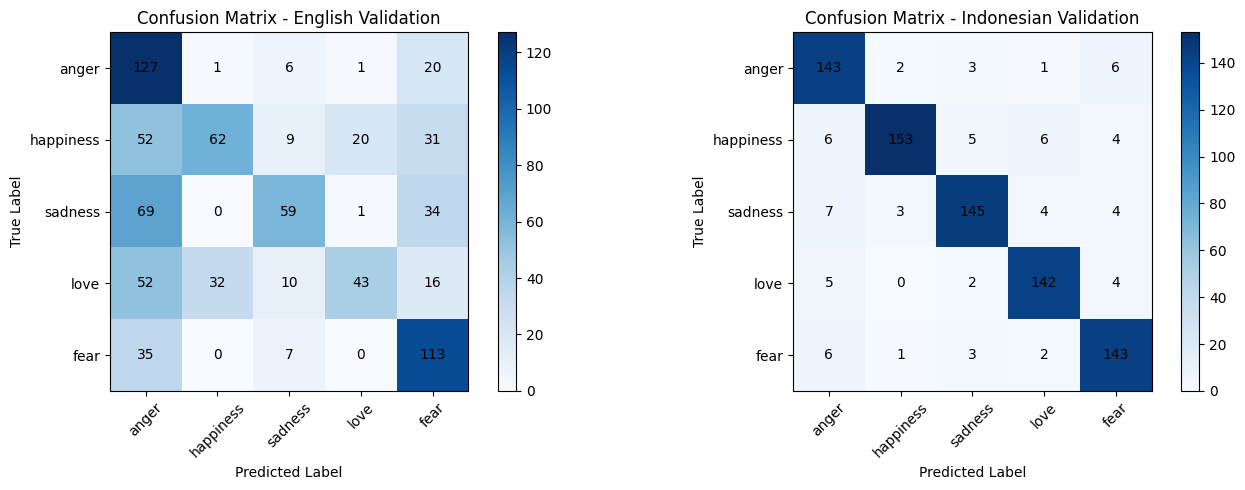

ENGLISH VALIDATION SET
              precision    recall  f1-score   support

       anger       0.38      0.82      0.52       155
   happiness       0.65      0.36      0.46       174
     sadness       0.65      0.36      0.46       163
        love       0.66      0.28      0.39       153
        fear       0.53      0.73      0.61       155

    accuracy                           0.51       800
   macro avg       0.57      0.51      0.49       800
weighted avg       0.58      0.51      0.49       800

INDONESIAN VALIDATION SET
              precision    recall  f1-score   support

       anger       0.86      0.92      0.89       155
   happiness       0.96      0.88      0.92       174
     sadness       0.92      0.89      0.90       163
        love       0.92      0.93      0.92       153
        fear       0.89      0.92      0.91       155

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91     

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import torch

# Collect all predictions and true labels for EN validation set
all_preds_en = []
all_labels_en = []
with torch.no_grad():
    for X_batch, y_batch in emotion_data_eng_val:
        X_batch = X_batch.to(next(probe.parameters()).device)
        outputs = probe(X_batch)
        predicted = torch.argmax(outputs, dim=1)
        all_preds_en.extend(predicted.cpu().numpy())
        all_labels_en.extend(y_batch.numpy())

# Collect all predictions and true labels for ID validation set
all_preds_id = []
all_labels_id = []
with torch.no_grad():
    for X_batch, y_batch in emotion_data_id_val:
        X_batch = X_batch.to(next(probe.parameters()).device)
        outputs = probe(X_batch)
        predicted = torch.argmax(outputs, dim=1)
        all_preds_id.extend(predicted.cpu().numpy())
        all_labels_id.extend(y_batch.numpy())

# Compute confusion matrices
cm_en = confusion_matrix(all_labels_en, all_preds_en, labels=range(len(all_emotions)))
cm_id = confusion_matrix(all_labels_id, all_preds_id, labels=range(len(all_emotions)))

# Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# English confusion matrix
im_en = axes[0].imshow(cm_en, cmap='Blues')
axes[0].set_xticks(range(len(all_emotions)))
axes[0].set_yticks(range(len(all_emotions)))
axes[0].set_xticklabels(all_emotions, rotation=45)
axes[0].set_yticklabels(all_emotions)
axes[0].set_title('Confusion Matrix - English Validation')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
# Add annotations
for i in range(len(all_emotions)):
    for j in range(len(all_emotions)):
        axes[0].text(j, i, str(cm_en[i, j]), ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im_en, ax=axes[0])

# Indonesian confusion matrix
im_id = axes[1].imshow(cm_id, cmap='Blues')
axes[1].set_xticks(range(len(all_emotions)))
axes[1].set_yticks(range(len(all_emotions)))
axes[1].set_xticklabels(all_emotions, rotation=45)
axes[1].set_yticklabels(all_emotions)
axes[1].set_title('Confusion Matrix - Indonesian Validation')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
# Add annotations
for i in range(len(all_emotions)):
    for j in range(len(all_emotions)):
        axes[1].text(j, i, str(cm_id[i, j]), ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im_id, ax=axes[1])

plt.tight_layout()
plt.show()

# Print classification reports
print("=" * 60)
print("ENGLISH VALIDATION SET")
print("=" * 60)
print(classification_report(all_labels_en, all_preds_en, target_names=all_emotions))

print("=" * 60)
print("INDONESIAN VALIDATION SET")
print("=" * 60)
print(classification_report(all_labels_id, all_preds_id, target_names=all_emotions))

# Mantel Test between different steering vectors

,anger,happiness,sadness,love,fear
anger,1.000000,-0.540271,0.150042,-0.606109,0.178716
happiness,-0.540271,1.000000,-0.464207,0.687524,-0.698205
sadness,0.150042,-0.464207,1.000000,-0.549593,0.381912
love,-0.606109,0.687524,-0.549593,1.000000,-0.726445
fear,0.178716,-0.698205,0.381912,-0.726445,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,0.542532,-0.471628,-0.804029,0.779932
happiness,0.542532,1.000000,-0.558193,-0.876152,0.733189
sadness,-0.471628,-0.558193,1.000000,0.477763,-0.467894
love,-0.804029,-0.876152,0.477763,1.000000,-0.926039
fear,0.779932,0.733189,-0.467894,-0.926039,1.000000


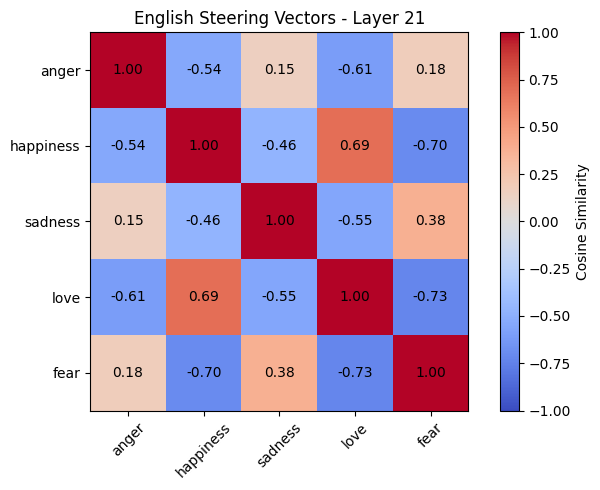

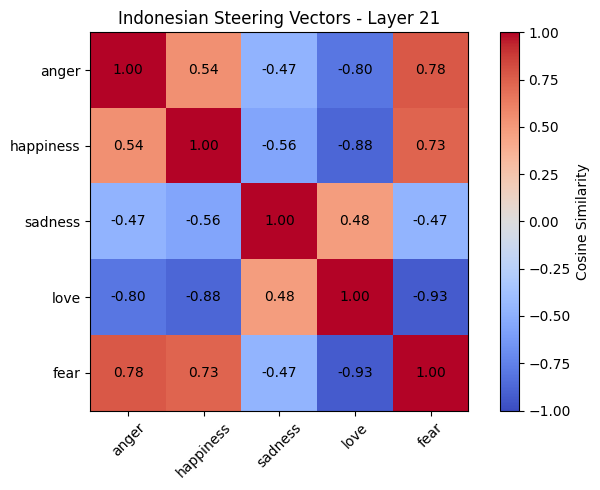

In [4]:


import matplotlib.pyplot as plt

emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_idx = 21

eng_cosine_matrix = analysis.build_cosine_matrix(steering_vector_eng, emotions, layer_idx)
id_cosine_matrix = analysis.build_cosine_matrix(steering_vector_id, emotions, layer_idx)

display(eng_cosine_matrix)
display(id_cosine_matrix)

plt.figure(figsize=(7, 5))
eng_plot = plt.imshow(eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('English Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), eng_cosine_matrix.values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
id_plot = plt.imshow(id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('Indonesian Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), id_cosine_matrix.values)
plt.tight_layout()
plt.show()

In [13]:
mantel_test_result = analysis.mantel_test(eng_cosine_matrix.values, id_cosine_matrix.values, num_permutations=1000)
print(f'Mantel Test Result: {mantel_test_result}')

Mantel Test Result: (np.float64(-0.26093655989224085), 0.453)


# Cosine Similarity across layers 

,emotion,layer,cosine_similarity
0,anger,0,0.262442
1,anger,1,0.986448
2,anger,2,0.968251
3,anger,3,0.919748
4,anger,4,0.855297


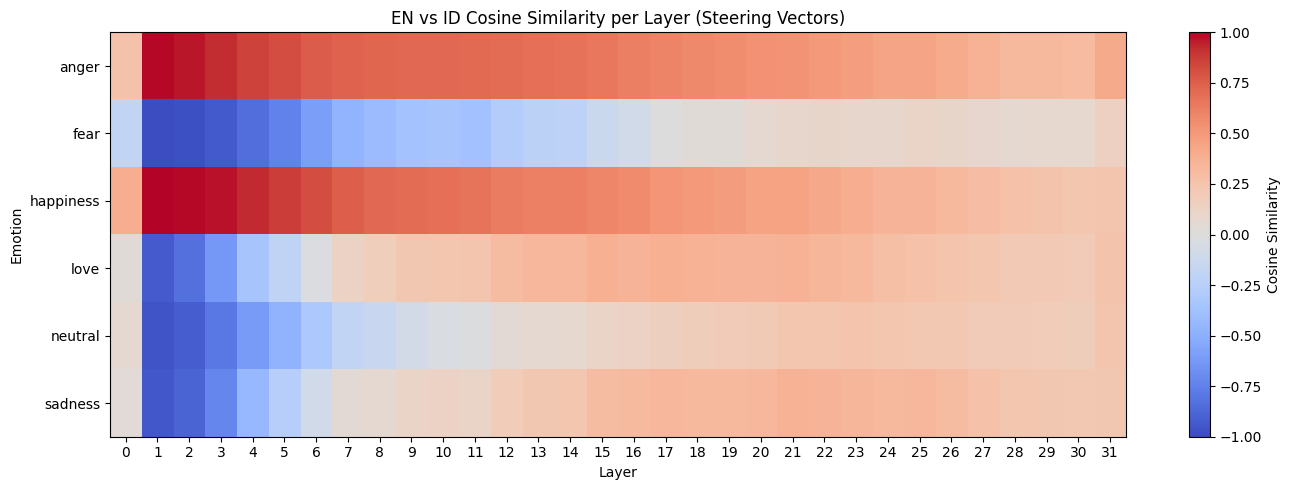

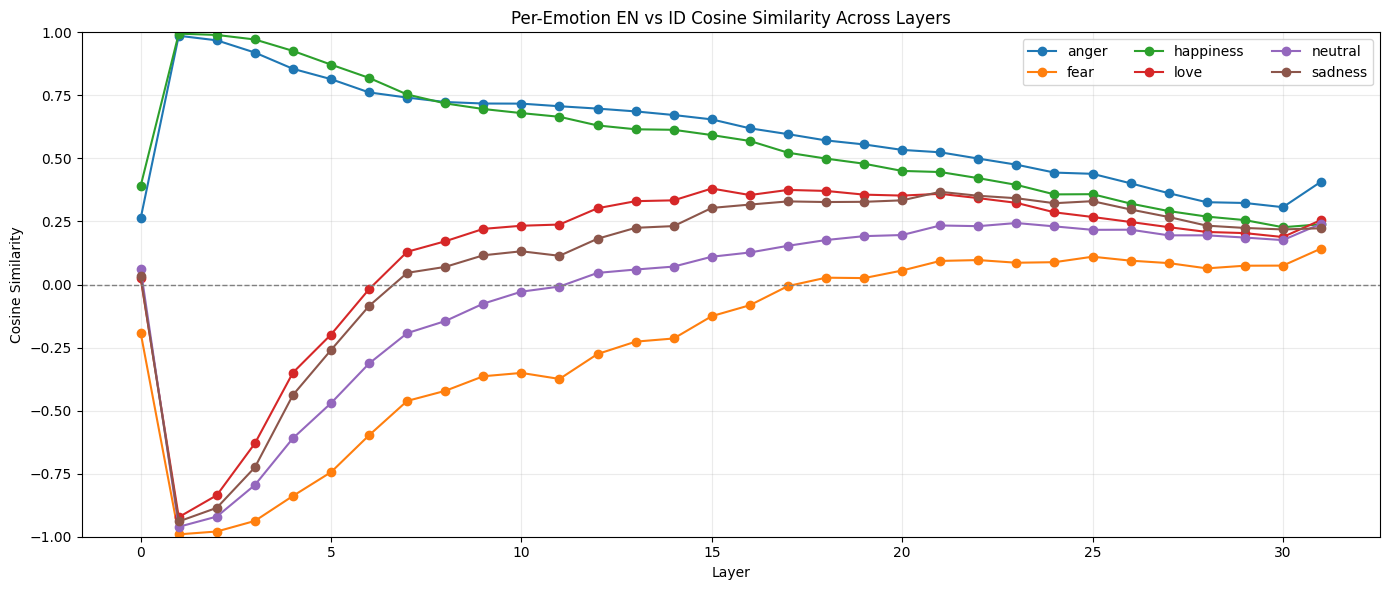

,mean,min,max
emotion,,,
anger,0.602258,0.262442,0.986448
happiness,0.563509,0.227269,0.994790
love,0.129181,-0.922400,0.380684
sadness,0.091719,-0.939441,0.367609
neutral,-0.029900,-0.960747,0.243885
fear,-0.220618,-0.990620,0.142518


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Cosine similarity per layer between EN and ID steering vectors for each emotion
emotions = ["anger", "happiness", "sadness", "love", "fear", "neutral"]
available_emotions = [
    e for e in emotions
    if e in steering_vector_eng and e in steering_vector_id
]

records = []
for emotion in available_emotions:
    en_vec = steering_vector_eng[emotion]
    id_vec = steering_vector_id[emotion]

    if en_vec.shape != id_vec.shape:
        raise ValueError(
            f"Shape mismatch for emotion '{emotion}': EN {en_vec.shape} vs ID {id_vec.shape}"
        )

    layer_sims = F.cosine_similarity(en_vec, id_vec, dim=1)
    for layer_idx, sim in enumerate(layer_sims.tolist()):
        records.append(
            {
                "emotion": emotion,
                "layer": layer_idx,
                "cosine_similarity": sim,
            }
        )

cosine_df = pd.DataFrame(records)
display(cosine_df.head())

# Pivot for heatmap-like matrix: rows = emotions, cols = layers
heatmap_df = cosine_df.pivot(index="emotion", columns="layer", values="cosine_similarity")

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_df.values, aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Cosine Similarity")
plt.yticks(ticks=np.arange(len(heatmap_df.index)), labels=heatmap_df.index)
plt.xticks(ticks=np.arange(len(heatmap_df.columns)), labels=heatmap_df.columns)
plt.xlabel("Layer")
plt.ylabel("Emotion")
plt.title("EN vs ID Cosine Similarity per Layer (Steering Vectors)")
plt.tight_layout()
plt.show()

# Line plot per emotion across layers
plt.figure(figsize=(14, 6))
for emotion in heatmap_df.index:
    plt.plot(heatmap_df.columns, heatmap_df.loc[emotion].values, marker="o", linewidth=1.5, label=emotion)

plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.ylim(-1, 1)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Per-Emotion EN vs ID Cosine Similarity Across Layers")
plt.legend(loc="best", ncol=3)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Optional summary table (mean/min/max similarity per emotion)
summary_df = (
    cosine_df.groupby("emotion")["cosine_similarity"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)
display(summary_df)

BIDIRECTIONAL TRANSFER: CLEAN COMPARISON

[1] Training probe on ENGLISH data...
Epoch 1/25, Loss: 1.5615
Validation Accuracy: 0.4637
Epoch 2/25, Loss: 1.3951
Validation Accuracy: 0.5950
Epoch 3/25, Loss: 1.2686
Validation Accuracy: 0.5875
Epoch 4/25, Loss: 1.1826
Validation Accuracy: 0.6288
Epoch 5/25, Loss: 1.1018
Validation Accuracy: 0.6312
Epoch 6/25, Loss: 1.0380
Validation Accuracy: 0.6175
Epoch 7/25, Loss: 0.9781
Validation Accuracy: 0.6238
Epoch 8/25, Loss: 0.9282
Validation Accuracy: 0.6362
Epoch 9/25, Loss: 0.8969
Validation Accuracy: 0.6562
Epoch 10/25, Loss: 0.8576
Validation Accuracy: 0.6613
Epoch 11/25, Loss: 0.8244
Validation Accuracy: 0.6713
Epoch 12/25, Loss: 0.7987
Validation Accuracy: 0.6650
Epoch 13/25, Loss: 0.7739
Validation Accuracy: 0.6625
Epoch 14/25, Loss: 0.7531
Validation Accuracy: 0.6750
Epoch 15/25, Loss: 0.7319
Validation Accuracy: 0.6587
Epoch 16/25, Loss: 0.7090
Validation Accuracy: 0.6713
Epoch 17/25, Loss: 0.6916
Validation Accuracy: 0.6725
Epoch 18/25

,Direction,Accuracy
0,EN → EN,0.67625
1,EN → ID,0.69500
2,ID → ID,0.90250
3,ID → EN,0.50500


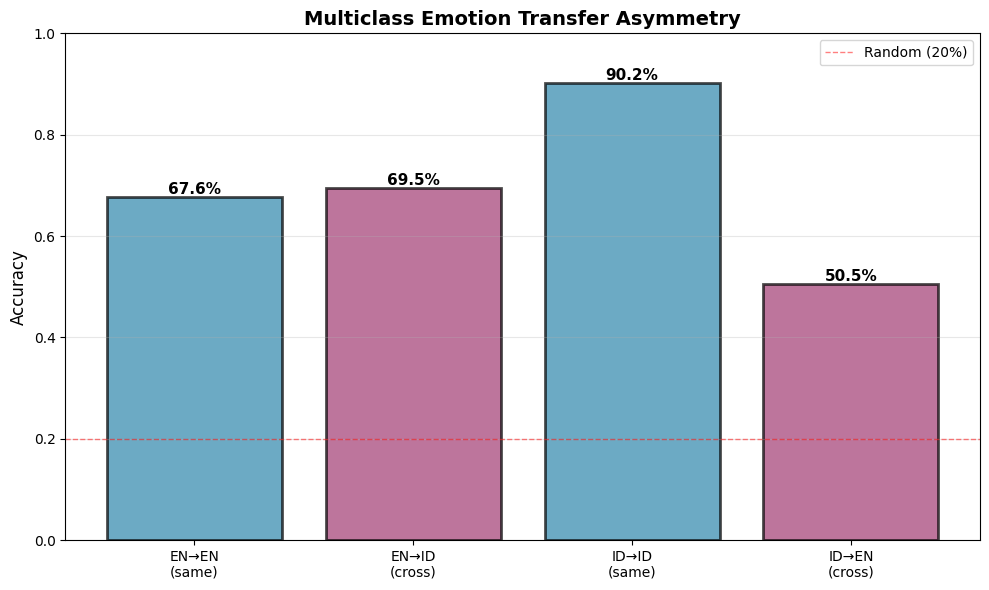

In [21]:
# Clean bidirectional transfer analysis
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("BIDIRECTIONAL TRANSFER: CLEAN COMPARISON")
print("="*70)

# Train probe on ENGLISH
print("\n[1] Training probe on ENGLISH data...")
probe_en_fresh = analysis.LogisticRegressionProbe(
    input_dim=emotion_vector_eng[all_emotions[0]][0].shape[-1],
    output_dim=len(all_emotions),
)
probe_en_fresh = analysis.trainMultiClassProbe(
    probe_en_fresh, emotion_data_eng_train, emotion_data_eng_val, num_epochs=25
)

en_self = float(analysis.predictProbe(probe_en_fresh, emotion_data_eng_val, multiclass=True).mean())
en_to_id = float(analysis.predictProbe(probe_en_fresh, emotion_data_id_val, multiclass=True).mean())
print(f"EN trained, tested on EN: {en_self:.4f}")
print(f"EN trained, tested on ID: {en_to_id:.4f}")
print(f"Transfer drop EN→ID: {en_self - en_to_id:.4f}")

# Train probe on INDONESIAN  
print("\n[2] Training probe on INDONESIAN data...")
probe_id_fresh = analysis.LogisticRegressionProbe(
    input_dim=emotion_vector_id[all_emotions[0]][0].shape[-1],
    output_dim=len(all_emotions),
)
probe_id_fresh = analysis.trainMultiClassProbe(
    probe_id_fresh, emotion_data_id_train, emotion_data_id_val, num_epochs=25
)

id_self = float(analysis.predictProbe(probe_id_fresh, emotion_data_id_val, multiclass=True).mean())
id_to_en = float(analysis.predictProbe(probe_id_fresh, emotion_data_eng_val, multiclass=True).mean())
print(f"ID trained, tested on ID: {id_self:.4f}")
print(f"ID trained, tested on EN: {id_to_en:.4f}")
print(f"Transfer drop ID→EN: {id_self - id_to_en:.4f}")

# Summary comparison
print("\n" + "="*70)
print("TRANSFER SUMMARY")
print("="*70)
transfer_summary = pd.DataFrame({
    'Direction': ['EN → EN', 'EN → ID', 'ID → ID', 'ID → EN'],
    'Accuracy': [en_self, en_to_id, id_self, id_to_en],
})
display(transfer_summary)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
directions = ['EN→EN\n(same)', 'EN→ID\n(cross)', 'ID→ID\n(same)', 'ID→EN\n(cross)']
accuracies = [en_self, en_to_id, id_self, id_to_en]
colors = ['#2E86AB', '#A23B72', '#2E86AB', '#A23B72']

bars = ax.bar(directions, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Multiclass Emotion Transfer Asymmetry', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.axhline(0.2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random (20%)')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()